In this heat attack Prediction: On the basis of past diagnostic test data of several patients, creating models for predicting the chances of having heart attack in near future.

About dataset:

Age, Sex CPT=Chest pain type RBP=Resting blood pressure Cholestoral FBS=Fasting blood sugar > 120 mg/dl RER=Resting electrocardiographic results (values 0,1,2) MAX.HR=Maximum heart rate achieved Exercise induced angina Oldpeak = ST depression induced by exercise relative to rest Slope of the peak exercise ST segment Number of major vessels (0-3) colored by flourosopy Thal: 0 = normal; 1 = fixed defect; 2 = reversable defect Target:- Target: 0= less chance of heart attack 1= more chance of heart attack

We have compared two model logistic regression and Support Vector Machine concluded that SVM gives the best accuracy.

In [33]:
import pandas as pd # data processing
import numpy as np # working with arrays
import matplotlib.pyplot as plt # visualization
from matplotlib import rcParams # figure size
from termcolor import colored as cl # text customization
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier as dtree # tree algorithm
from sklearn.model_selection import train_test_split # splitting the data
from sklearn.metrics import accuracy_score # model precision
from sklearn.tree import plot_tree # tree diagram
from sklearn.metrics import log_loss

In [34]:
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

In [35]:
df= pd.read_excel('DATASET_HEART_ATTACK_POSSIBILITY.xlsx')

In [36]:
df.head()

,Age,Sex,CPT,RBP,Cholestoral,FBS,RER,MAX.HR,Exercise,Oldpeak,Slope,Major vessels,Thal,Target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [37]:
df.isnull().any()

Age              False
Sex              False
CPT              False
RBP              False
Cholestoral      False
FBS              False
RER              False
MAX.HR           False
Exercise         False
 Oldpeak         False
Slope            False
Major vessels    False
Thal             False
Target           False
dtype: bool

<Axes: xlabel='Target', ylabel='count'>

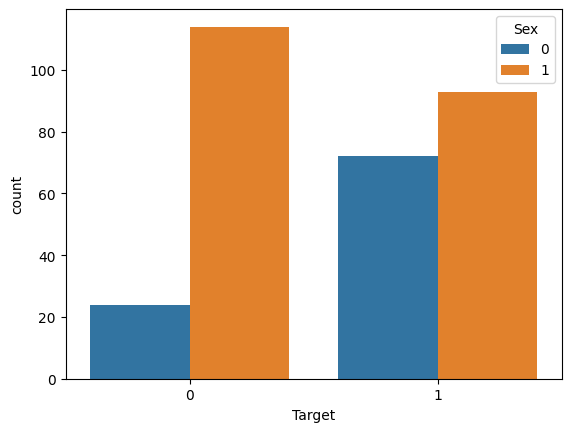

In [38]:
sns.countplot(x='Target', hue = 'Sex' , data= df)

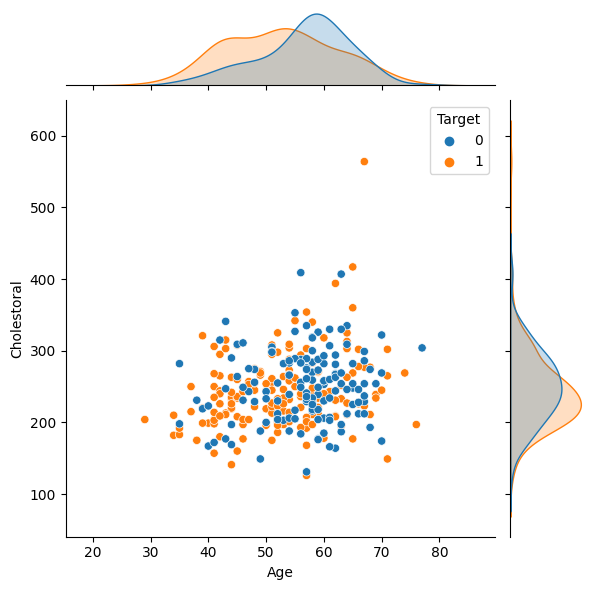

In [39]:
sns.jointplot(x='Age' , y = 'Cholestoral', data= df, hue='Target')

In [40]:
#sns.pairplot(df, hue='Target')

<Axes: >

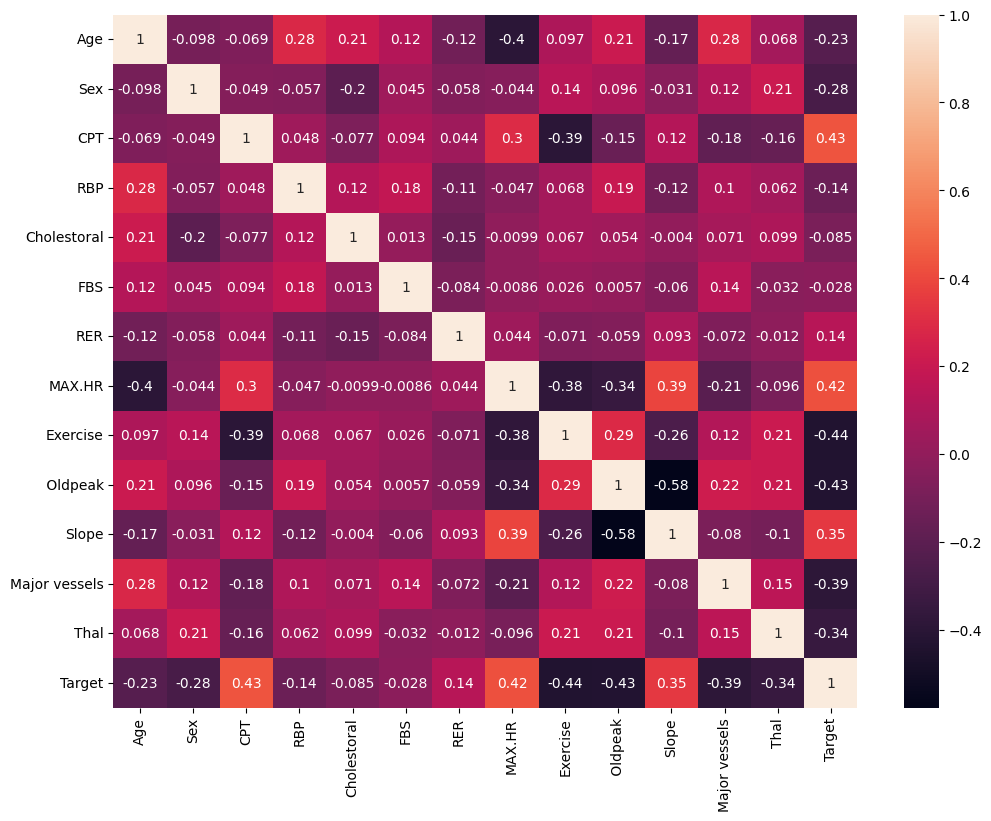

In [41]:
plt.figure(figsize=(12,9))
sns.heatmap(df.corr(), annot=True)

In [42]:
df.columns

Index(['Age', 'Sex', 'CPT', 'RBP', 'Cholestoral', 'FBS', 'RER', 'MAX.HR',
       'Exercise', ' Oldpeak', 'Slope', 'Major vessels', 'Thal', 'Target'],
      dtype='object')

In [43]:
X= df.drop(['Target'], axis=1)
y=df['Target']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

Logistic Regression:

In [45]:
#logistic regression raw
from sklearn.linear_model import LogisticRegression
glm= LogisticRegression()
model= glm.fit(X_train, y_train)
predictions= glm.predict(X_test)

In [46]:
accuracy_train = accuracy_score(y_test,predictions)
print('\naccuracy_score on test dataset : ', accuracy_train)


accuracy_score on test dataset :  0.8064516129032258


In [47]:
#hyper-parameter tuning for logistic regression
param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter':[100,200,500,600,800]
}

# Create GridSearchCV object
grid_search = GridSearchCV(glm, param_grid, cv=5, n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print best hyperparameters and corresponding score
print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best hyperparameters: {'C': 1, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best cross-validation score: 0.8308417508417509


SVM

In [48]:
#SVM RAW
from sklearn.svm import SVC
svc_model = SVC()
svc_model.fit(X_train, y_train)
predictions = svc_model.predict(X_test)

In [49]:
accuracy_train = accuracy_score(y_test,predictions)
print('\naccuracy_score on test dataset : ', accuracy_train)


accuracy_score on test dataset :  0.8064516129032258


In [50]:
#SVM hyper tuned
# Define a smaller grid of hyperparameters to search
param_grid = {
    'C': [1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.1]
}

# Create GridSearchCV object
grid_search = GridSearchCV(svc_model, param_grid, cv=5, n_jobs=-1)
# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print best hyperparameters and corresponding score
print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best hyperparameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation score: 0.8234343434343433


In [51]:
###mlp raw 
from sklearn.neural_network import MLPClassifier
model=MLPClassifier()
model.fit(X_train,y_train)
predictions=model.predict(X_test)

In [52]:
accuracy_train = accuracy_score(y_test,predictions)
print('\naccuracy_score on test dataset : ', accuracy_train)


accuracy_score on test dataset :  0.8387096774193549


In [53]:
#mlp huper tuned
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01]
}

# Create GridSearchCV object
grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print best hyperparameters and corresponding score
print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best hyperparameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (50, 50), 'solver': 'lbfgs'}
Best cross-validation score: 0.8345454545454546


In [54]:
#building the algorithims with the best parameters

In [55]:
svc_model = SVC(C=10,gamma='scale',kernel='linear')

In [56]:
logistic_reg=LogisticRegression(C=1,max_iter=100,penalty= 'l1', solver='liblinear')

In [57]:
MLP=MLPClassifier(activation= 'relu', alpha= 0.0001, hidden_layer_sizes= (50, 50), solver= 'lbfgs')

In [58]:
#fitting all of them
svc_model.fit(X_train,y_train)
logistic_reg.fit(X_train,y_train)
MLP.fit(X_train,y_train)

MLPClassifier(hidden_layer_sizes=(50, 50), solver='lbfgs')

In [61]:
#calculculate the loss
svc_predictions=svc_model.predict(X_test)
log_reg_predictions=logistic_reg.predict(X_test)
mlp_predict=MLP.predict(X_test)

In [62]:
from sklearn.metrics import log_loss
log_loss_value = log_loss(y_test, log_reg_predictions)
svc_loss_value = log_loss(y_test, svc_predictions)
mlp_loss_value = log_loss(y_test, mlp_predict)
print("Log Loss for logistic regression:", svc_loss_value)
print("Log Loss for SVC:", log_loss_value)
print("Log Loss for MLP:", mlp_loss_value)


Log Loss for logistic regression: 5.813492482115669
Log Loss for SVC: 6.976190978538803
Log Loss for MLP: 8.138889474961937
